In [1]:
import numpy as np
import pandas as pd
import os
from scipy.optimize import linprog
from scipy.sparse import csr_matrix, vstack
import networkx as nx
import random

In [2]:
# Seed

seed = 42
rng = np.random.default_rng(seed=seed)
np.random.seed(seed)
random.seed(seed)

In [3]:
file_name = "clickstream-enwiki-2025-10.tsv"
data_path = os.path.join("./data", file_name)
columns = ["prev", "curr", "type", "n"]
data = pd.read_csv(data_path, sep="\t", names=columns, on_bad_lines="skip")
print(data.shape)
data.head()

(36531778, 4)


,prev,curr,type,n
0,other-empty,Main_Page,external,168686293.0
1,UK_Album_Downloads_Chart,Lists_of_UK_Album_Downloads_Chart_number_ones,link,14.0
2,other-search,Ed_Gein,external,20339579.0
3,UK_Albums_Chart,Ed_Sheeran,link,14.0
4,other-empty,Google_Chrome,external,11955074.0


In [4]:
nan_rows = data[data.isnull().any(axis=1)]
print(nan_rows.shape)
nan_rows.head()

(128, 4)


,prev,curr,type,n
280484,other-search,NaN,external,5253.0
387272,other-search,NaN,external,3949.0
423668,other-empty,NaN,external,3640.0
733595,other-empty,NaN,external,2180.0
1244445,other-external,NaN,external,1308.0


In [5]:
data = data.dropna()
print(data.shape)

(36531650, 4)


In [6]:
data = data[
    (data["type"] == "link")
    & (~data["prev"].str.startswith("other-"))
    & (~data["curr"].str.startswith("other-"))
]
print(data.shape)
data.head()

(23056437, 4)


,prev,curr,type,n
1,UK_Album_Downloads_Chart,Lists_of_UK_Album_Downloads_Chart_number_ones,link,14.0
3,UK_Albums_Chart,Ed_Sheeran,link,14.0
5,UK_Albums_Chart,"Whatever_People_Say_I_Am,_That's_What_I'm_Not",link,14.0
7,UK_Carrier_Strike_Group,HMS_Diamond_(D34),link,14.0
9,UK_Carrier_Strike_Group,Steadfast_Defender_2024,link,14.0


In [7]:
def build_topic_subgraph(df, topic, max_nodes=100):
    mask = df["prev"].str.contains(topic, case=False) | df["curr"].str.contains(
        topic, case=False
    )

    df_topic = df[mask].copy()

    counts_prev = df_topic.groupby("prev")["n"].sum()
    counts_curr = df_topic.groupby("curr")["n"].sum()
    scores = counts_prev.add(counts_curr, fill_value=0)

    top_pages_titles = (
        scores.sort_values(ascending=False).head(max_nodes).index.tolist()
    )

    df_sub = df_topic[
        df_topic["prev"].isin(top_pages_titles)
        & df_topic["curr"].isin(top_pages_titles)
    ].copy()

    pages = sorted(set(df_sub["prev"]).union(df_sub["curr"]))
    page_to_idx = {p: i for i, p in enumerate(pages)}

    df_sub["i"] = df_sub["prev"].map(page_to_idx)
    df_sub["j"] = df_sub["curr"].map(page_to_idx)

    n = len(pages)

    return df_sub, n, pages


def build_P(df, n, alpha=0.05):
    w = np.zeros((n, n), dtype=float)

    for _, row in df.iterrows():
        i = row["i"]
        j = row["j"]
        w[i, j] += row["n"]

    P0 = np.zeros_like(w)

    # calculate sum of rows for normalization
    row_sums = w.sum(axis=1)
    for i in range(n):
        if row_sums[i] > 0:
            P0[i, :] = w[i, :] / row_sums[i]
        else:
            P0[i, :] = 0

    # replace zero rows with v T
    v = np.ones(n) / n
    for i in range(n):
        if row_sums[i] == 0:
            P0[i, :] = v

    P_tilde0 = (1 - alpha) * P0 + alpha * np.outer(np.ones(n), v)

    return P0, P_tilde0, w

In [8]:
def solve_tsdp_L1_full_edges(P_tilde0, pi_star, w, C=None):
    n = P_tilde0.shape[0]

    if C is None:
        C = np.ones_like(P_tilde0)

    w_loops = w.copy()
    eps = 1e-9
    for i in range(n):
        if w_loops[i, i] == 0:
            w_loops[i, i] = eps

    edges = [(i, j) for i in range(n) for j in range(n)]
    m = len(edges)

    num_P = m
    num_t = m
    num_vars = num_P + num_t

    c = np.zeros(num_vars)
    c[num_P:] = [C[i, j] for (i, j) in edges]

    A_eq = []
    b_eq = []

    outgoing = {i: [] for i in range(n)}
    incoming = {j: [] for j in range(n)}
    for e_idx, (i, j) in enumerate(edges):
        outgoing[i].append((e_idx, j))
        incoming[j].append((e_idx, i))

    for i in range(n):
        row = np.zeros(num_vars)

        for e_idx, j in outgoing[i]:
            row[e_idx] = 1.0

        Bi = 0.0
        if len(outgoing[i]) < n:
            js_in_omega = {j for (_, j) in outgoing[i]}
            for j in range(n):
                if j not in js_in_omega:
                    Bi += P_tilde0[i, j]

        A_eq.append(row)
        b_eq.append(1.0 - Bi)

    for j in range(n):
        row = np.zeros(num_vars)

        for e_idx, i in incoming[j]:
            row[e_idx] = pi_star[i]

        Sj = 0.0
        if len(incoming[j]) < n:
            is_in_omega = {i for (_, i) in incoming[j]}
            for i in range(n):
                if i not in is_in_omega:
                    Sj += pi_star[i] * P_tilde0[i, j]

        A_eq.append(row)
        b_eq.append(pi_star[j] - Sj)

    A_eq = np.vstack(A_eq)
    b_eq = np.array(b_eq)

    A_ub = []
    b_ub = []

    for e_idx, (i, j) in enumerate(edges):
        idx_P = e_idx
        idx_t = num_P + e_idx
        P0_ij = P_tilde0[i, j]

        r1 = np.zeros(num_vars)
        r1[idx_P] = 1.0
        r1[idx_t] = -1.0
        A_ub.append(r1)
        b_ub.append(P0_ij)

        r2 = np.zeros(num_vars)
        r2[idx_P] = -1.0
        r2[idx_t] = -1.0
        A_ub.append(r2)
        b_ub.append(-P0_ij)

    A_ub = np.vstack(A_ub)
    b_ub = np.array(b_ub)

    bounds = [(0.0, 1.0)] * num_P + [(0.0, None)] * num_t

    res = linprog(
        c, A_eq=A_eq, b_eq=b_eq, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs"
    )

    if not res.success:
        print("LP failed:", res.message)
        return None, None, edges

    x = res.x
    P_edges = x[:num_P]
    t_edges = x[num_P:]

    P_opt = P_tilde0.copy()
    for val, (i, j) in zip(P_edges, edges):
        P_opt[i, j] = val

    return P_opt, t_edges, edges

In [9]:
def solve_tsdp_L1(P_tilde0, pi_star, w, C=None, k_in=10, k_out=10):
    n = P_tilde0.shape[0]

    # specific nodes with conditions
    if C is None:
        C = np.ones_like(P_tilde0)

    # ========== EDGES ==========
    edges_set = {(int(i), int(j)) for i, j in np.argwhere(w > 0)}

    # add out edges
    for i in range(n):
        # add self-loops
        edges_set.add((i, i))
        js = np.argsort(P_tilde0[i])[::-1][:k_out]
        for j in js:
            edges_set.add((i, j))

    # add incoming edges
    for j in range(n):
        if pi_star[j] > 0 and not any((i, j) in edges_set for i in range(n)):
            isrc = np.argsort(P_tilde0[:, j])[::-1][:k_in]
            for i in isrc:
                edges_set.add((i, j))

    edges = sorted(edges_set)
    m = len(edges)

    num_P = m
    num_t = m
    num_vars = num_P + num_t

    print(f"[INFO] n={n}, |Ω|={m}")

    outgoing = {i: [] for i in range(n)}
    incoming = {j: [] for j in range(n)}
    for e_idx, (i, j) in enumerate(edges):
        outgoing[i].append((e_idx, j))
        incoming[j].append((e_idx, i))

    # ========== COST ==========
    c = np.zeros(num_vars)
    c[num_P:] = [C[i, j] for (i, j) in edges]

    data_r = []
    rows_r = []
    cols_r = []
    b_rows = np.zeros(n)

    # sum of worws P should be equal to 1
    # The algorithm must edit only edges from omega
    for i in range(n):
        js_omega = {j for (_, j) in outgoing[i]}
        Bi = P_tilde0[i].sum() - sum(P_tilde0[i, j] for j in js_omega)
        b_rows[i] = 1.0 - Bi
        for e_idx, j in outgoing[i]:
            rows_r.append(i)
            cols_r.append(e_idx)
            data_r.append(1.0)

    A_rows = csr_matrix((data_r, (rows_r, cols_r)), shape=(n, num_vars))

    data_s = []
    rows_s = []
    cols_s = []
    RHS_stat = np.zeros(n)

    # Stationary
    # pi * P = pi
    for j in range(n):
        is_omega = {i for (_, i) in incoming[j]}
        Sj = sum(pi_star[i] * P_tilde0[i, j] for i in range(n) if i not in is_omega)
        RHS_stat[j] = pi_star[j] - Sj
        for e_idx, i in incoming[j]:
            rows_s.append(j)
            cols_s.append(e_idx)
            data_s.append(pi_star[i])

    A_stat = csr_matrix((data_s, (rows_s, cols_s)), shape=(n, num_vars))

    A_eq = vstack([A_rows, A_stat], format="csr")
    b_eq = np.concatenate([b_rows, RHS_stat])

    data_u = []
    rows_u = []
    cols_u = []
    b_ub = np.zeros(2 * m)

    # L1 norm
    # data  = [10, 20, 30]
    # rows  = [ 0,  1,  2]
    # cols  = [ 1,  2,  0]
    # | row\col | 0  | 1  | 2  |
    # | ------- | -- | -- | -- |
    # | 0       | 0  | 10 | 0  |
    # | 1       | 0  | 0  | 20 |
    # | 2       | 30 | 0  | 0  |

    for k, (i, j) in enumerate(edges):
        idxP = k
        idxT = m + k
        P0 = P_tilde0[i, j]

        # A_ub[2*k, idxP] = 1
        # A_ub[2*k, idxT] = -1

        rows_u.extend([2 * k, 2 * k])
        cols_u.extend([idxP, idxT])
        data_u.extend([1.0, -1.0])
        b_ub[2 * k] = P0

        # A_ub[2*k+1, idxP] = -1
        # A_ub[2*k+1, idxT] = -1

        rows_u.extend([2 * k + 1, 2 * k + 1])
        cols_u.extend([idxP, idxT])
        data_u.extend([-1.0, -1.0])
        b_ub[2 * k + 1] = -P0

    A_ub = csr_matrix((data_u, (rows_u, cols_u)), shape=(2 * m, num_vars))

    bounds = [(0.0, 1.0)] * num_P + [(0.0, None)] * num_t

    print("[INFO] Running HiGHS...")

    res = linprog(
        c, A_eq=A_eq, b_eq=b_eq, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs"
    )

    if not res.success:
        print("[ERROR] LP failed:", res.message)
        return None, None, edges

    print("[INFO] LP solved.")

    x = res.x
    P_edges = x[:num_P]

    P_opt = P_tilde0.copy()
    for val, (i, j) in zip(P_edges, edges):
        P_opt[i, j] = val

    return P_opt, x[num_P:], edges

In [10]:
def solve_tsdp_Linf(P_tilde0, pi_star, w, C=None, k_in=10, k_out=10):
    n = P_tilde0.shape[0]
    if C is None:
        C = np.ones_like(P_tilde0)

    edges_set = {(i, j) for i, j in np.argwhere(w > 0)}

    for i in range(n):
        edges_set.add((i, i))
        js = np.argsort(P_tilde0[i])[::-1][:k_out]
        for j in js:
            edges_set.add((i, j))

    for j in range(n):
        if pi_star[j] > 0 and not any((i, j) in edges_set for i in range(n)):
            isrc = np.argsort(P_tilde0[:, j])[::-1][:k_in]
            for i in isrc:
                edges_set.add((i, j))

    edges = sorted(edges_set)
    m = len(edges)
    print(f"[INFO] n={n}, |Ω|={m}")

    num_P = m
    num_T = 1
    num_vars = num_P + num_T
    idx_T = num_P

    outgoing = {i: [] for i in range(n)}
    incoming = {j: [] for j in range(n)}
    for e_idx, (i, j) in enumerate(edges):
        outgoing[i].append((e_idx, j))
        incoming[j].append((e_idx, i))

    c = np.zeros(num_vars)
    c[idx_T] = 1.0

    data_r, rows_r, cols_r = [], [], []
    b_rows = np.zeros(n)

    for i in range(n):
        js_omega = {j for (_, j) in outgoing[i]}
        Bi = P_tilde0[i].sum() - sum(P_tilde0[i, j] for j in js_omega)
        b_rows[i] = 1.0 - Bi
        for e_idx, j in outgoing[i]:
            rows_r.append(i)
            cols_r.append(e_idx)
            data_r.append(1.0)

    A_rows = csr_matrix((data_r, (rows_r, cols_r)), shape=(n, num_vars))

    data_s, rows_s, cols_s = [], [], []
    RHS_stat = np.zeros(n)

    for j in range(n):
        is_omega = {i for (_, i) in incoming[j]}
        Sj = sum(pi_star[i] * P_tilde0[i, j] for i in range(n) if i not in is_omega)
        RHS_stat[j] = pi_star[j] - Sj
        for e_idx, i in incoming[j]:
            rows_s.append(j)
            cols_s.append(e_idx)
            data_s.append(pi_star[i])

    A_stat = csr_matrix((data_s, (rows_s, cols_s)), shape=(n, num_vars))

    A_eq = vstack([A_rows, A_stat], format="csr")
    b_eq = np.concatenate([b_rows, RHS_stat])

    data_u, rows_u, cols_u = [], [], []
    b_ub = np.zeros(2 * m)

    for k, (i, j) in enumerate(edges):
        P0 = P_tilde0[i, j]
        Ce = C[i, j] if np.isscalar(C) == False else C

        rows_u.extend([2 * k, 2 * k])
        cols_u.extend([k, idx_T])
        data_u.extend([Ce, -1.0])
        b_ub[2 * k] = Ce * P0

        rows_u.extend([2 * k + 1, 2 * k + 1])
        cols_u.extend([k, idx_T])
        data_u.extend([-Ce, -1.0])
        b_ub[2 * k + 1] = -Ce * P0

    A_ub = csr_matrix((data_u, (rows_u, cols_u)), shape=(2 * m, num_vars))

    bounds = [(0.0, 1.0)] * num_P + [(0.0, None)]

    print("[INFO] Running HiGHS (L_inf)...")
    res = linprog(
        c,
        A_eq=A_eq,
        b_eq=b_eq,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=bounds,
        method="highs",
    )

    if not res.success:
        print("[ERROR] LP failed:", res.message)
        return None, None, edges

    print("[INFO] LP solved (L_inf).")

    x = res.x
    P_edges = x[:num_P]
    T_opt = x[idx_T]

    P_opt = P_tilde0.copy()
    for val, (i, j) in zip(P_edges, edges):
        P_opt[i, j] = val

    return P_opt, T_opt, edges

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def stationary_distribution(P, tol=1e-14, max_iter=20000):
    n = P.shape[0]
    pi = np.ones(n) / n
    for _ in range(max_iter):
        new = pi @ P
        new = new / new.sum()
        if np.sum(np.abs(new - pi)) < tol:
            return new
        pi = new
    return pi

In [12]:
df_sub, n, pages = build_topic_subgraph(data, topic="Football", max_nodes=20)
print("Subgraph size:", n)

P0, P_tilde0, w = build_P(df_sub, n, alpha=0.05)

pi_base = stationary_distribution(P_tilde0)
beta = 0.1

# pi_star = (1 - beta) * pi_base + beta * (np.ones(n) / n)
# pi_star /= pi_star.sum()

pi_star = np.ones(n) / n

# Does not work for some max_nodes (100-2000) because of infeasibility
P_opt, t_edges, edges = solve_tsdp_L1(P_tilde0, pi_star, w, k_in=10, k_out=10)

Subgraph size: 20
[INFO] n=20, |Ω|=220
[INFO] Running HiGHS...
[INFO] LP solved.


## Solution verification

In [13]:
def verify_solution(P, pi_star, row_tol=1e-9, neg_tol=-1e-12, pi_tol=1e-8):
    if P is None:
        print("Infeasible")
        return "Infeasible"
    n = P.shape[0]

    product = P @ np.ones(n)
    row_err = np.max(np.abs(product - 1))

    P_min = P.min()

    pi = stationary_distribution(P)
    pi_err = np.sum(np.abs(pi - pi_star))

    print("\n===== FEASIBILITY CHECK =====")
    print(f"max |P1 - 1|       = {row_err:.3e}   (target < {row_tol})")
    print(f"min P_ij           = {P_min:.3e}     (allowed >= {neg_tol})")
    print(f"Deviation L1(pi(P), pi_star) = {pi_err:.3e}   (target < {pi_tol})")

    feasible = row_err < row_tol and P_min >= neg_tol and pi_err < pi_tol

    print("Feasible?", feasible)
    print("=============================\n")

    return {
        "row_error": row_err,
        "min_P": P_min,
        "pi_error": pi_err,
        "feasible": feasible,
        "pi(P)": pi,
    }

In [14]:
results = verify_solution(P_opt, pi_star)


===== FEASIBILITY CHECK =====
max |P1 - 1|       = 3.997e-15   (target < 1e-09)
min P_ij           = 0.000e+00     (allowed >= -1e-12)
Deviation L1(pi(P), pi_star) = 2.984e-16   (target < 1e-08)
Feasible? True



## Evaluation

### Metrics

In [15]:
def calculate_metrics(
    P_tilde0, P_opt, pi_star, edges, C=None, ks=(1, 2, 5, 10, 20), eps=1e-6
):
    n = P_tilde0.shape[0]
    if C is None:
        C = np.ones_like(P_tilde0)

    Delta_full = np.abs(P_opt - P_tilde0)

    mask = np.zeros_like(Delta_full, dtype=bool)
    for i, j in edges:
        mask[i, j] = True

    Delta = np.where(mask, Delta_full, 0.0)

    # Edit cost
    edit_cost = np.sum(C * Delta)

    # Deviation
    pi_opt = stationary_distribution(P_opt)
    deviation_stationary_distrib = np.sum(np.abs(pi_opt - pi_star))

    # sparsity
    changed = np.sum(Delta > eps)
    sparsity = 1 - changed / (n * n)

    # L1, L_inf
    L1 = np.sum(np.abs(Delta))
    L_inf = np.max(Delta)

    mixing_norms = []
    for k in ks:
        Pk = np.linalg.matrix_power(P_opt, k)
        target_rank1 = np.ones((n, 1)) @ pi_star.reshape(1, -1)
        diff = Pk - target_rank1
        mixing_norms.append(np.sum(np.abs(diff)))

    print("=== TSDP Evaluation ===")
    print(f"Edit cost (sum c_ij * |Δ_ij|): {edit_cost:.6f}")
    print(f"‖Δ‖_1:  {L1:.6f}")
    print(f"‖Δ‖_∞:  {L_inf:.6f}")
    print(f"Sparsity: {sparsity:.6f}")
    print("‖π(P_opt) − π*‖_1:", deviation_stationary_distrib)
    print()
    print("Mixing proxy ‖P^k − 1π*^T‖_1:")
    for k, val in zip(ks, mixing_norms):
        print(f"  k={k:2d}: {val:.6f}")

In [16]:
if P_opt is None:
    print("LP infeasible")
else:
    results = calculate_metrics(P_tilde0, P_opt, pi_star, edges)

=== TSDP Evaluation ===
Edit cost (sum c_ij * |Δ_ij|): 8.754831
‖Δ‖_1:  8.754831
‖Δ‖_∞:  0.659035
Sparsity: 0.790000
‖π(P_opt) − π*‖_1: 2.983724378680108e-16

Mixing proxy ‖P^k − 1π*^T‖_1:
  k= 1: 29.244446
  k= 2: 22.220564
  k= 5: 12.689358
  k=10: 7.825396
  k=20: 3.514182


### Plots

In [17]:
def plot_exposure_bars(P_tilde0, P_opt, pi_star, labels=None, top_k=20):
    n = P_tilde0.shape[0]
    if labels is None:
        labels = [f"p{i}" for i in range(n)]

    pi_base = stationary_distribution(P_tilde0)
    pi_opt = stationary_distribution(P_opt)

    order = np.argsort(pi_star)[::-1][:top_k]

    x = np.arange(len(order))
    width = 0.25

    plt.figure(figsize=(10, 8))
    plt.bar(x - width, pi_base[order], width, label="π(P0)")
    plt.bar(x, pi_star[order], width, label="π*")
    plt.bar(x + width, pi_opt[order], width, label="π(P_opt)")

    plt.xticks(x, [labels[i] for i in order], rotation=45, ha="right")
    plt.ylabel("Probability")
    plt.title(f"Before / target / after exposure for top-{top_k} pages")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_edge_change_network(
    P_tilde0, P_opt, edges, labels=None, eps=1e-6, width_scale=5.0, figsize=(7, 7)
):
    n = P_tilde0.shape[0]
    if labels is None:
        labels = [f"p{i}" for i in range(n)]

    Delta = np.abs(P_opt - P_tilde0)

    G = nx.DiGraph()
    for i in range(n):
        G.add_node(i, label=labels[i])

    edge_list = []
    widths = []
    for i, j in edges:
        w = Delta[i, j]
        if w > eps:
            G.add_edge(i, j, weight=w)
            edge_list.append((i, j))
            widths.append(w)

    if not edge_list:
        print("No edges with |Δ_ij| above threshold.")
        return

    widths = np.asarray(widths)
    max_w = widths.max()
    if max_w == 0:
        print("All Δ_ij values are zero.")
        return

    norm_widths = width_scale * widths / max_w
    pos = nx.spring_layout(G, seed=0)

    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_size=700, alpha=0.9)
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edge_list,
        width=norm_widths,
        arrows=True,
        arrowstyle="-|>",
        alpha=0.8,
    )
    nx.draw_networkx_labels(
        G, pos, labels={i: labels[i] for i in G.nodes}, font_size=10
    )

    plt.title("Edge-change network: width ∝ |P_ij − P̃0_ij|")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def plot_delta_heatmap(P_tilde0, P_opt, labels=None):
    n = P_tilde0.shape[0]
    if labels is None:
        labels = [f"p{i}" for i in range(n)]

    Delta = np.abs(P_opt - P_tilde0)

    plt.figure(figsize=(8, 6))
    plt.imshow(Delta, aspect="equal")
    plt.colorbar(label="|Δ_ij|")

    plt.title("Heatmap of Δ = |P − P~0|")
    plt.tight_layout()
    plt.show()

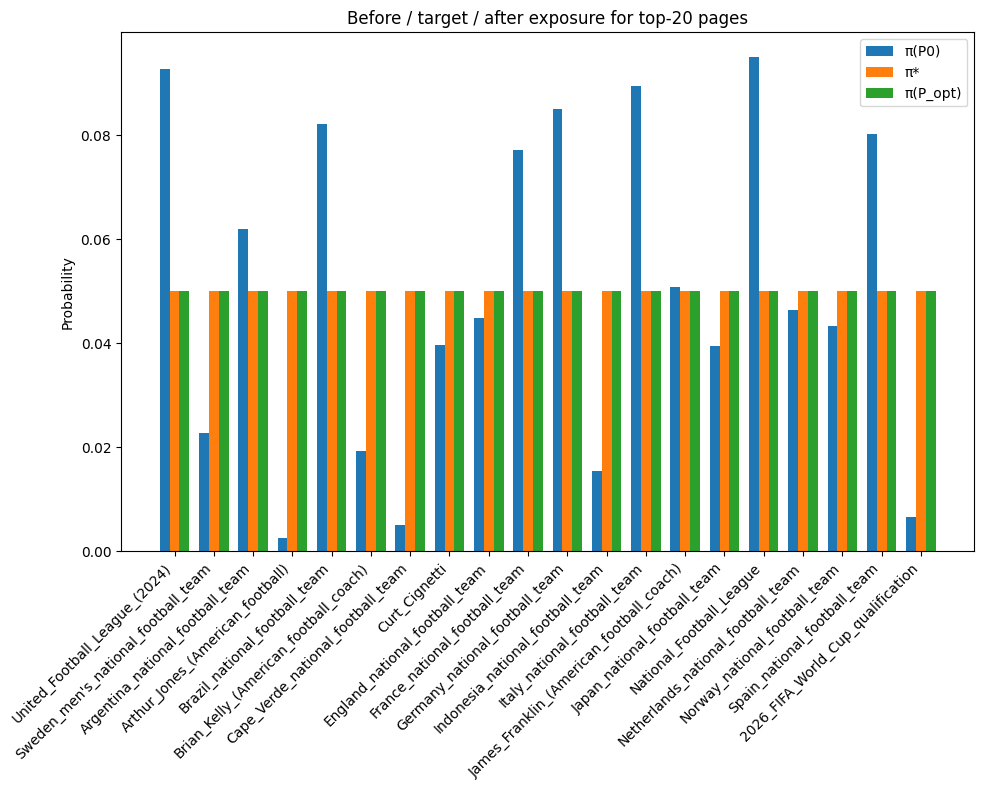

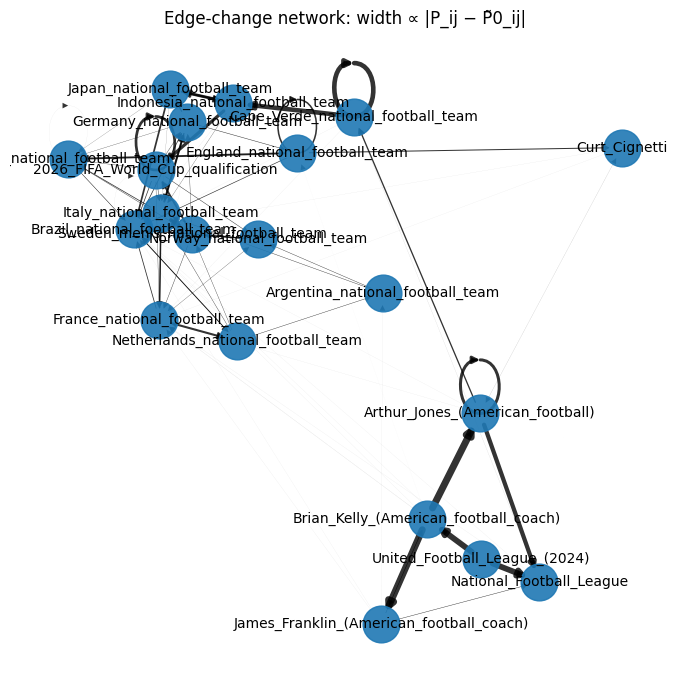

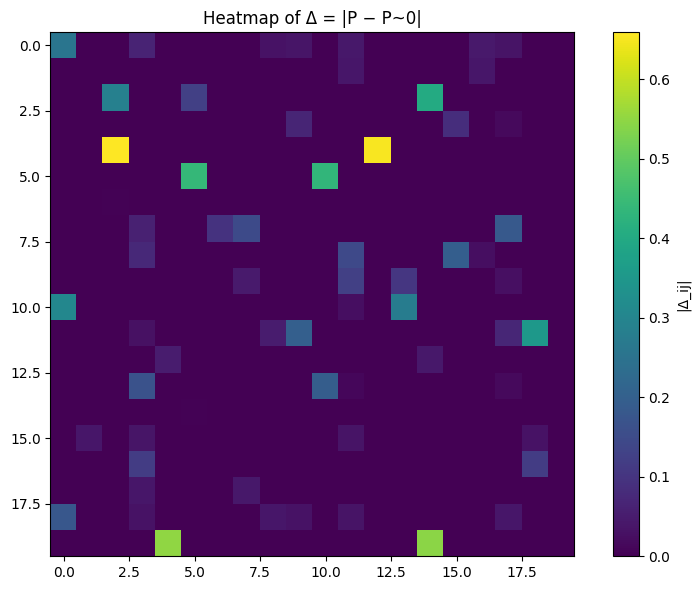

In [18]:
plot_exposure_bars(P_tilde0, P_opt, pi_star, labels=pages, top_k=20)
plot_edge_change_network(P_tilde0, P_opt, edges, pages)
plot_delta_heatmap(P_tilde0, P_opt, labels=pages)

## Experiments

### Small dataset 200 nodes

In [19]:
df_sub, n, pages = build_topic_subgraph(data, topic="Football", max_nodes=200)
print("Subgraph size:", n)

P0, P_tilde0, w = build_P(df_sub, n, alpha=0.05)

pi_base = stationary_distribution(P_tilde0)
beta = 0.1

# pi_star = (1 - beta) * pi_base + beta * (np.ones(n) / n)
# pi_star /= pi_star.sum()

pi_star = np.ones(n) / n

Subgraph size: 200


In [20]:
k_in = 5
k_out = 5

## Cost

### Degree-weighted edit cost

In [21]:
n = P_tilde0.shape[0]
C = np.ones_like(P_tilde0)

out_deg = w.sum(axis=1)
eps = 1e-9
for i in range(n):
    wt = 1.0 / max(out_deg[i], eps)
    C[i, :] = wt

### L1

[INFO] n=200, |Ω|=4062
[INFO] Running HiGHS...
[INFO] LP solved.

===== FEASIBILITY CHECK =====
max |P1 - 1|       = 4.730e-14   (target < 1e-09)
min P_ij           = 0.000e+00     (allowed >= -1e-12)
Deviation L1(pi(P), pi_star) = 1.249e-15   (target < 1e-08)
Feasible? True

=== TSDP Evaluation ===
Edit cost (sum c_ij * |Δ_ij|): 106.300685
‖Δ‖_1:  106.300685
‖Δ‖_∞:  0.950250
Sparsity: 0.973825
‖π(P_opt) − π*‖_1: 1.2490009027033011e-15

Mixing proxy ‖P^k − 1π*^T‖_1:
  k= 1: 352.709566
  k= 2: 291.443761
  k= 5: 189.360074
  k=10: 123.794145
  k=20: 64.467627


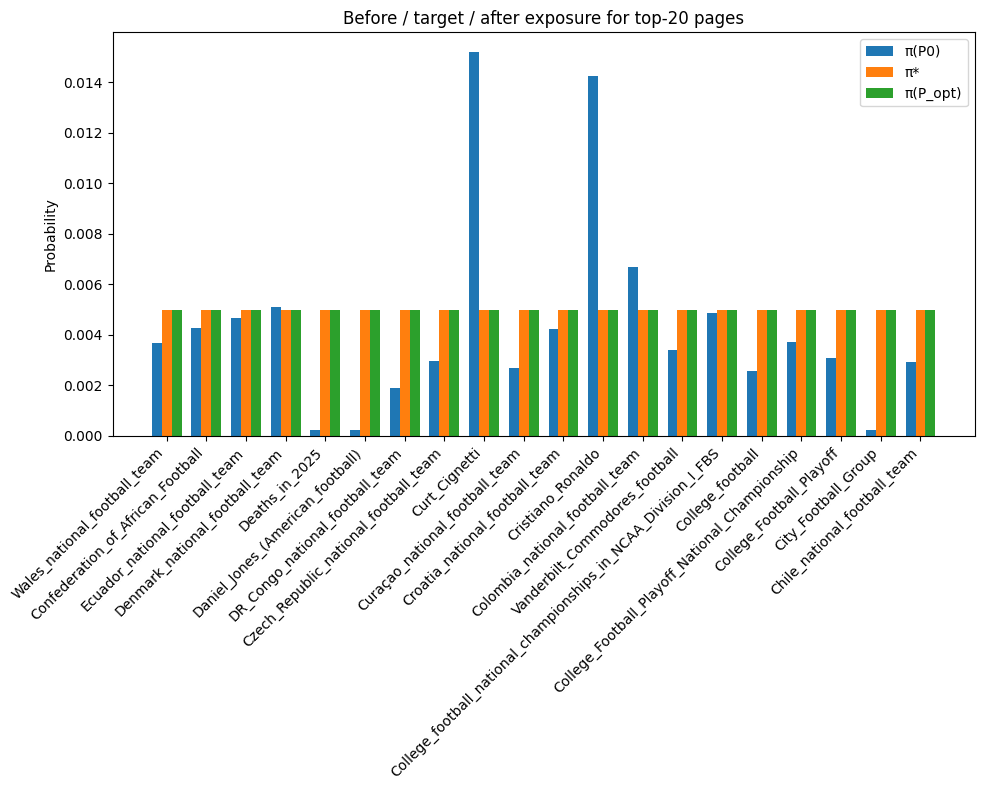

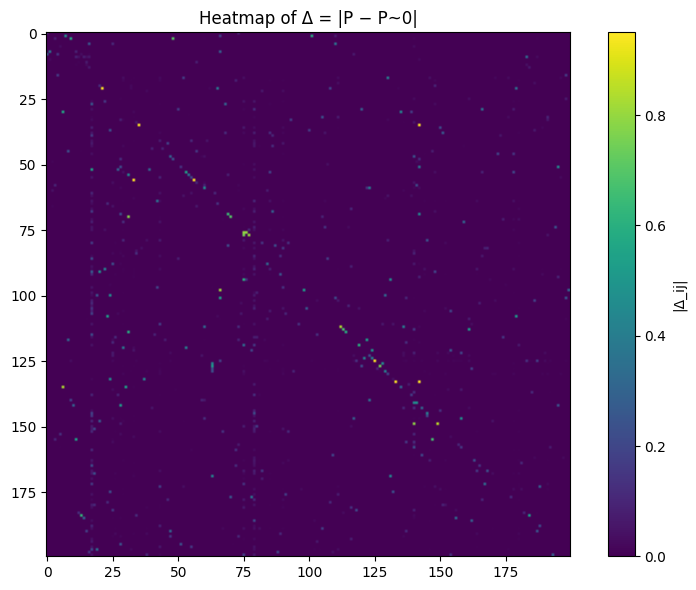

In [22]:
P_opt, t_edges, edges = solve_tsdp_L1(P_tilde0, pi_star, w, k_in=k_in, k_out=k_out)
results = verify_solution(P_opt, pi_star)

if P_opt is None:
    print("LP infeasible")
else:
    results = calculate_metrics(P_tilde0, P_opt, pi_star, edges)

plot_exposure_bars(P_tilde0, P_opt, pi_star, labels=pages, top_k=20)
plot_delta_heatmap(P_tilde0, P_opt, labels=pages)

### L inf

[INFO] n=200, |Ω|=4062
[INFO] Running HiGHS (L_inf)...
[INFO] LP solved (L_inf).

===== FEASIBILITY CHECK =====
max |P1 - 1|       = 6.661e-16   (target < 1e-09)
min P_ij           = -0.000e+00     (allowed >= -1e-12)
Deviation L1(pi(P), pi_star) = 1.933e-15   (target < 1e-08)
Feasible? True

=== TSDP Evaluation ===
Edit cost (sum c_ij * |Δ_ij|): 351.633840
‖Δ‖_1:  351.633840
‖Δ‖_∞:  0.956240
Sparsity: 0.898450
‖π(P_opt) − π*‖_1: 1.9333493139761515e-15

Mixing proxy ‖P^k − 1π*^T‖_1:
  k= 1: 378.798000
  k= 2: 360.521239
  k= 5: 310.827178
  k=10: 242.770760
  k=20: 148.236195


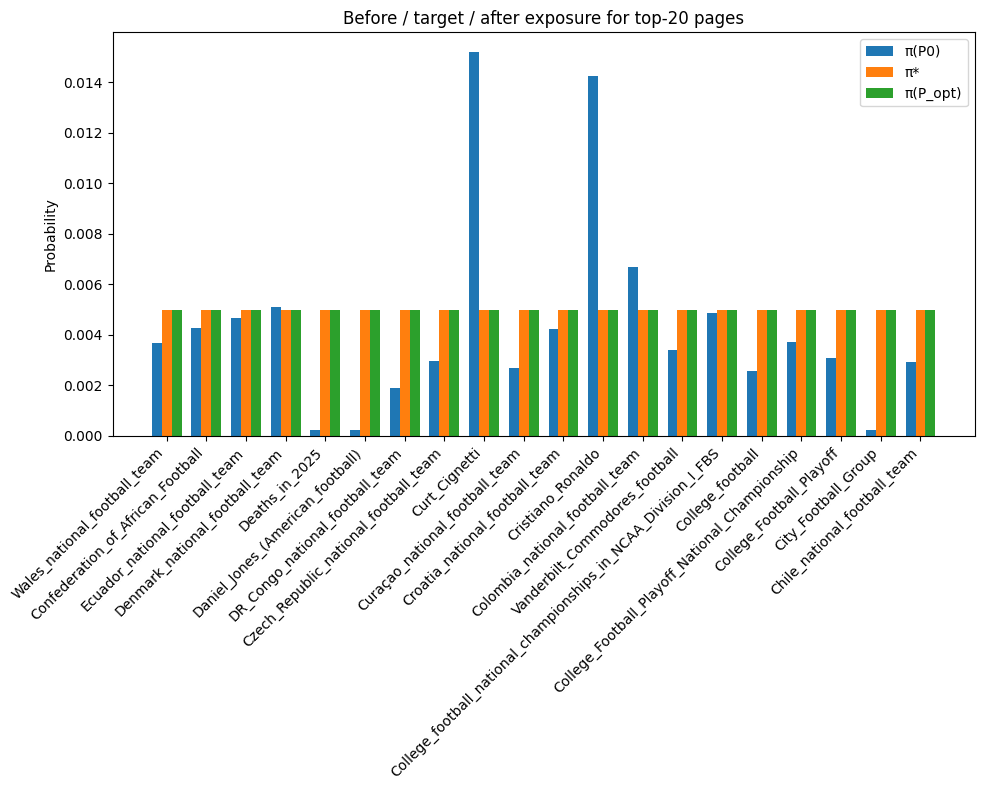

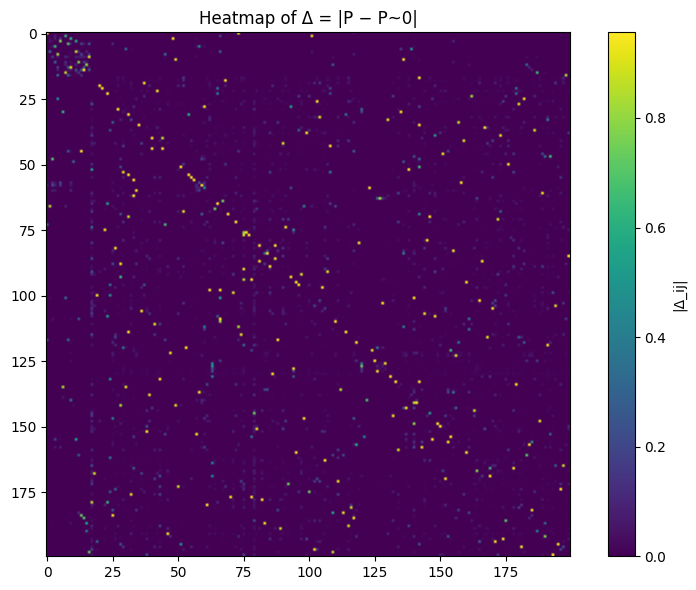

In [23]:
P_opt, t_edges, edges = solve_tsdp_Linf(
    P_tilde0, pi_star, w, C=C, k_in=k_in, k_out=k_out
)
results = verify_solution(P_opt, pi_star)

if P_opt is None:
    print("LP infeasible")
else:
    results = calculate_metrics(P_tilde0, P_opt, pi_star, edges)

plot_exposure_bars(P_tilde0, P_opt, pi_star, labels=pages, top_k=20)
plot_delta_heatmap(P_tilde0, P_opt, labels=pages)

### L 1

[INFO] n=200, |Ω|=4062
[INFO] Running HiGHS...
[INFO] LP solved.

===== FEASIBILITY CHECK =====
max |P1 - 1|       = 4.996e-14   (target < 1e-09)
min P_ij           = 0.000e+00     (allowed >= -1e-12)
Deviation L1(pi(P), pi_star) = 1.326e-15   (target < 1e-08)
Feasible? True

=== TSDP Evaluation ===
Edit cost (sum c_ij * |Δ_ij|): 111.932325
‖Δ‖_1:  111.932325
‖Δ‖_∞:  0.950000
Sparsity: 0.968600
‖π(P_opt) − π*‖_1: 1.326196097384269e-15

Mixing proxy ‖P^k − 1π*^T‖_1:
  k= 1: 354.116138
  k= 2: 295.776389
  k= 5: 190.862953
  k=10: 122.308611
  k=20: 62.481905


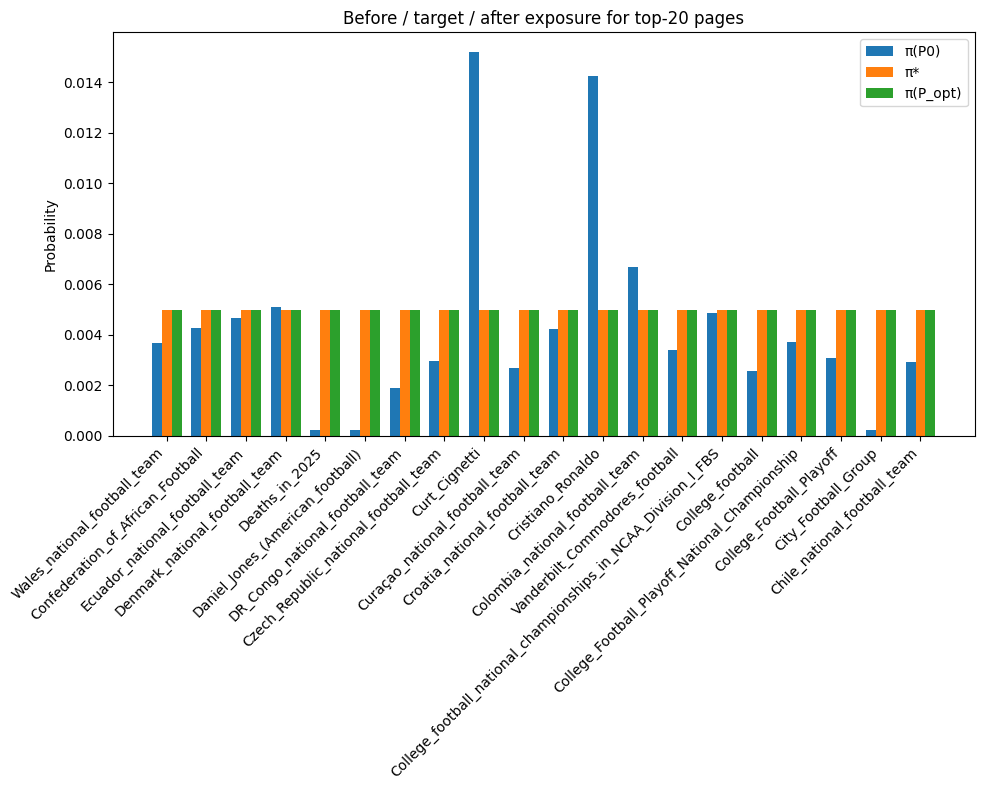

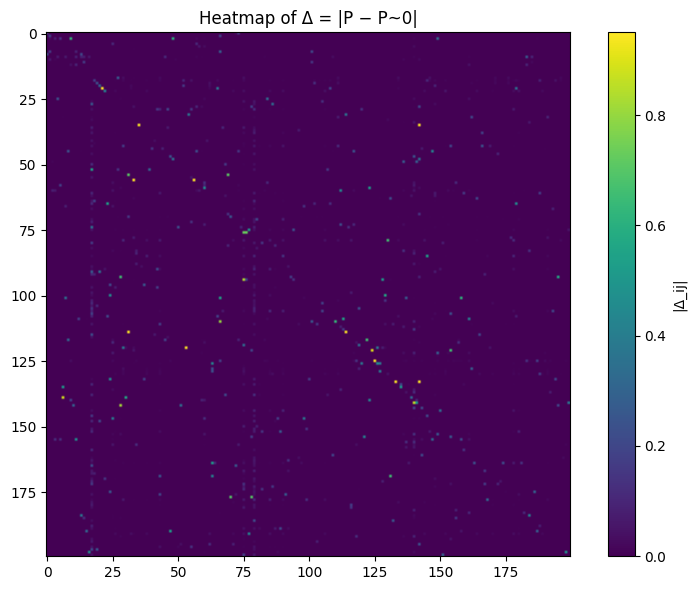

In [24]:
P_opt, t_edges, edges = solve_tsdp_L1(P_tilde0, pi_star, w, C=C, k_in=k_in, k_out=k_out)
results = verify_solution(P_opt, pi_star)

if P_opt is None:
    print("LP infeasible")
else:
    results = calculate_metrics(P_tilde0, P_opt, pi_star, edges)

plot_exposure_bars(P_tilde0, P_opt, pi_star, labels=pages, top_k=20)
plot_delta_heatmap(P_tilde0, P_opt, labels=pages)

### L inf

[INFO] n=200, |Ω|=4062
[INFO] Running HiGHS (L_inf)...
[INFO] LP solved (L_inf).

===== FEASIBILITY CHECK =====
max |P1 - 1|       = 3.708e-14   (target < 1e-09)
min P_ij           = -0.000e+00     (allowed >= -1e-12)
Deviation L1(pi(P), pi_star) = 1.736e-15   (target < 1e-08)
Feasible? True

=== TSDP Evaluation ===
Edit cost (sum c_ij * |Δ_ij|): 337.061613
‖Δ‖_1:  337.061613
‖Δ‖_∞:  0.950000
Sparsity: 0.898450
‖π(P_opt) − π*‖_1: 1.736458199452784e-15

Mixing proxy ‖P^k − 1π*^T‖_1:
  k= 1: 378.718492
  k= 2: 360.348868
  k= 5: 310.442127
  k=10: 242.021216
  k=20: 146.782184


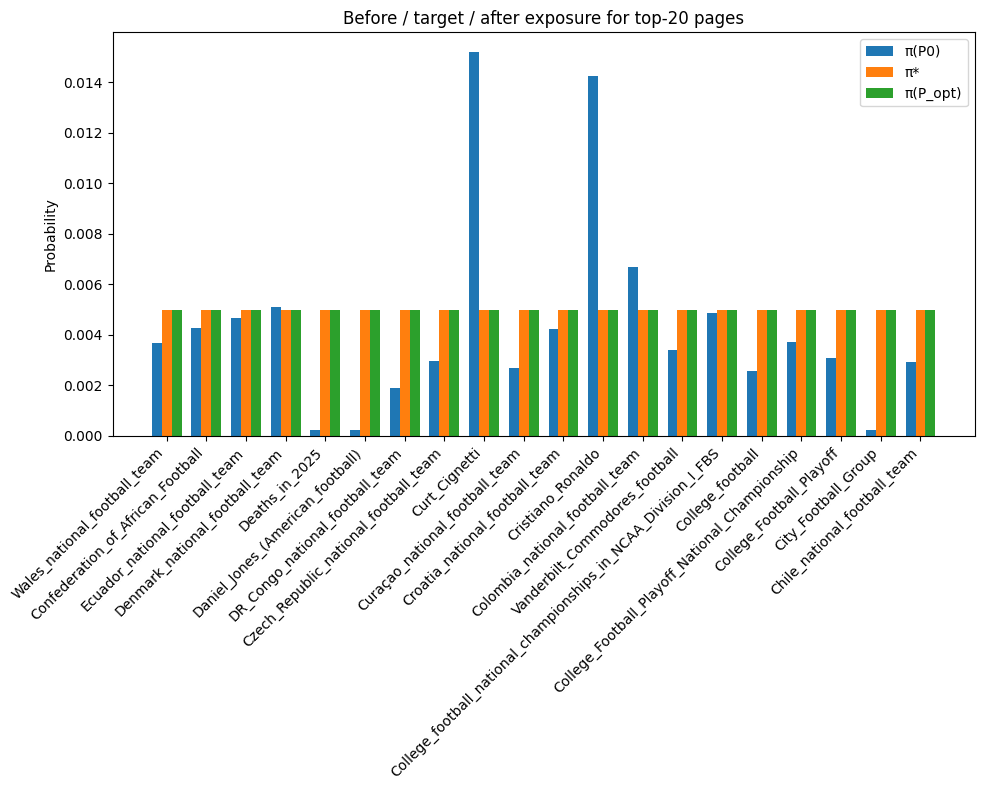

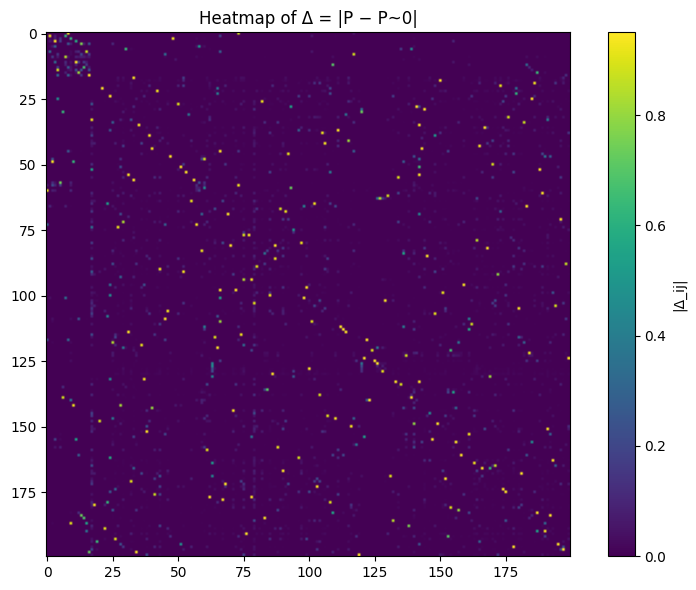

In [25]:
P_opt, t_edges, edges = solve_tsdp_Linf(P_tilde0, pi_star, w, k_in=k_in, k_out=k_out)
results = verify_solution(P_opt, pi_star)

if P_opt is None:
    print("LP infeasible")
else:
    results = calculate_metrics(P_tilde0, P_opt, pi_star, edges)

plot_exposure_bars(P_tilde0, P_opt, pi_star, labels=pages, top_k=20)
plot_delta_heatmap(P_tilde0, P_opt, labels=pages)

## Pertrubation

In [26]:
eps_list = [1e-6, 1e-5, 2e-5]

# pi_base = stationary_distribution(P_tilde0)

# pi_star = (1 - beta) * pi_base + beta * (np.ones(n) / n)
# pi_star /= pi_star.sum()

pi_star = np.ones(n) / n

for eps in eps_list:
    noise = rng.normal(size=n)
    noise -= noise.mean()

    noise_L1 = np.sum(np.abs(noise))
    if noise_L1 < 1e-15:
        continue

    noise = noise * (eps / noise_L1)

    pi_pert = pi_base + noise

    pi_pert = np.maximum(pi_pert, 0.0)
    s = pi_pert.sum()
    if s == 0:
        pi_pert = np.ones(n) / n
    else:
        pi_pert /= s

    l1_diff = np.sum(np.abs(pi_pert - pi_base))
    print(f"eps={eps}, actual L1(pi_pert - pi_base)={l1_diff:.6f}")

    P_opt, t_edges, edges = solve_tsdp_Linf(P_tilde0, pi_pert, w, k_in=15, k_out=15)

    if P_opt is None:
        print(f"eps={eps}: LP infeasible")
        print()
        print()
        continue

    verify_solution(P_opt, pi_pert)

    results = calculate_metrics(P_tilde0, P_opt, pi_pert, edges)

    print()
    print()

eps=1e-06, actual L1(pi_pert - pi_base)=0.000001
[INFO] n=200, |Ω|=4741
[INFO] Running HiGHS (L_inf)...
[INFO] LP solved (L_inf).

===== FEASIBILITY CHECK =====
max |P1 - 1|       = 7.772e-16   (target < 1e-09)
min P_ij           = 2.173e-04     (allowed >= -1e-12)
Deviation L1(pi(P), pi_star) = 1.441e-14   (target < 1e-08)
Feasible? True

=== TSDP Evaluation ===
Edit cost (sum c_ij * |Δ_ij|): 0.149328
‖Δ‖_1:  0.149328
‖Δ‖_∞:  0.000033
Sparsity: 0.882500
‖π(P_opt) − π*‖_1: 1.44055774253804e-14

Mixing proxy ‖P^k − 1π*^T‖_1:
  k= 1: 338.663562
  k= 2: 268.357808
  k= 5: 178.288645
  k=10: 121.606921
  k=20: 66.675671


eps=1e-05, actual L1(pi_pert - pi_base)=0.000010
[INFO] n=200, |Ω|=4741
[INFO] Running HiGHS (L_inf)...
[ERROR] LP failed: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
eps=1e-05: LP infeasible


eps=2e-05, actual L1(pi_pert - pi_base)=0.000020
[INFO] n=200, |Ω|=4741
[INFO] Running HiGHS (L_inf)...
[ERROR] LP failed: The pr

## Large dataset

In [27]:
df_sub, n, pages = build_topic_subgraph(data, topic="Football", max_nodes=1000)
print("Subgraph size:", n)

P0, P_tilde0, w = build_P(df_sub, n, alpha=0.05)

pi_base = stationary_distribution(P_tilde0)
beta = 0.1

# pi_star = (1 - beta) * pi_base + beta * (np.ones(n) / n)
# pi_star /= pi_star.sum()

pi_star = np.ones(n) / n

Subgraph size: 996


In [28]:
k_in = 5
k_out = 5

In [29]:
n = P_tilde0.shape[0]
C = np.ones_like(P_tilde0)

out_deg = w.sum(axis=1)
eps = 1e-9
for i in range(n):
    wt = 1.0 / max(out_deg[i], eps)
    C[i, :] = wt

### L1

[INFO] n=996, |Ω|=19512
[INFO] Running HiGHS...
[INFO] LP solved.

===== FEASIBILITY CHECK =====
max |P1 - 1|       = 1.554e-15   (target < 1e-09)
min P_ij           = 0.000e+00     (allowed >= -1e-12)
Deviation L1(pi(P), pi_star) = 1.643e-14   (target < 1e-08)
Feasible? True

=== TSDP Evaluation ===
Edit cost (sum c_ij * |Δ_ij|): 566.725578
‖Δ‖_1:  566.725578
‖Δ‖_∞:  0.950050
Sparsity: 0.992396
‖π(P_opt) − π*‖_1: 1.6426963955762375e-14

Mixing proxy ‖P^k − 1π*^T‖_1:
  k= 1: 1858.782520
  k= 2: 1669.782711
  k= 5: 1106.926946
  k=10: 657.268590
  k=20: 315.830771


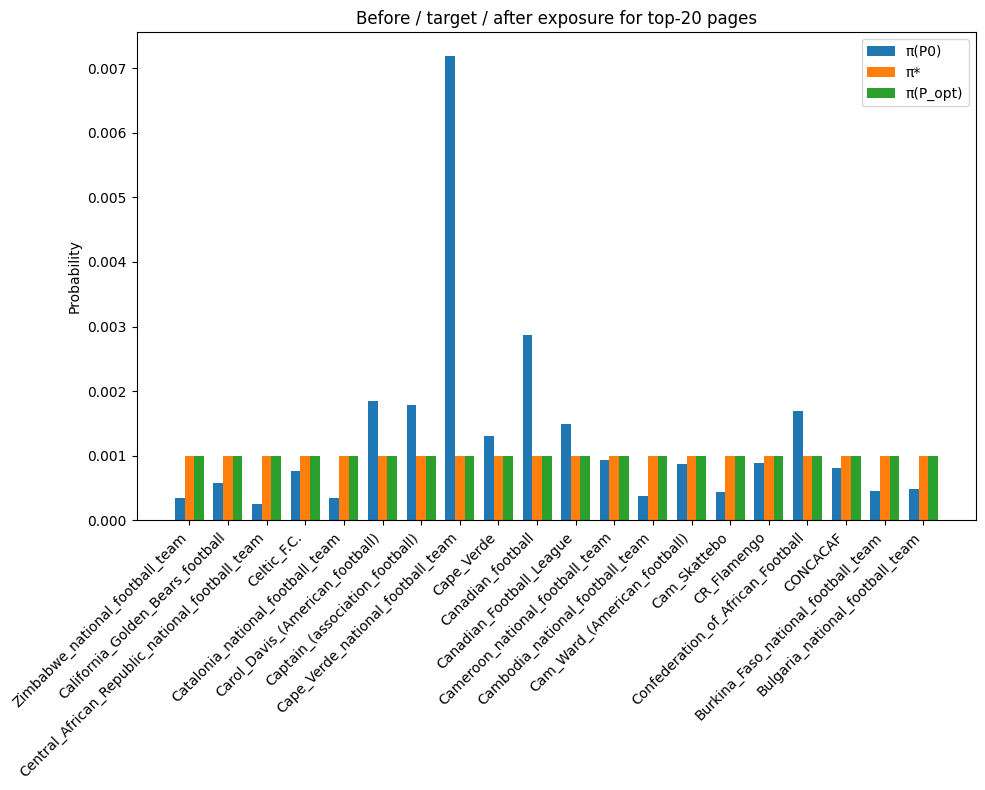

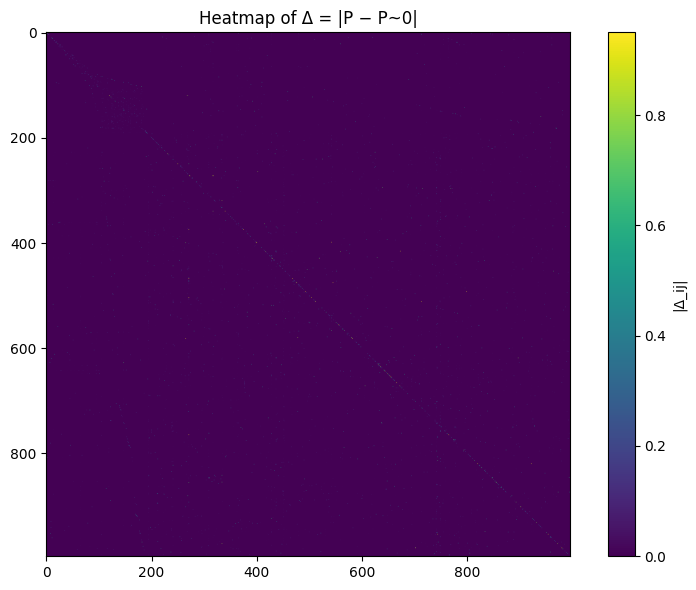

In [30]:
P_opt, t_edges, edges = solve_tsdp_L1(P_tilde0, pi_star, w, k_in=k_in, k_out=k_out)
results = verify_solution(P_opt, pi_star)

if P_opt is None:
    print("LP infeasible")
else:
    results = calculate_metrics(P_tilde0, P_opt, pi_star, edges)

plot_exposure_bars(P_tilde0, P_opt, pi_star, labels=pages, top_k=20)
plot_delta_heatmap(P_tilde0, P_opt, labels=pages)

### L inf

[INFO] n=996, |Ω|=19512
[INFO] Running HiGHS (L_inf)...
[INFO] LP solved (L_inf).

===== FEASIBILITY CHECK =====
max |P1 - 1|       = 1.332e-15   (target < 1e-09)
min P_ij           = 0.000e+00     (allowed >= -1e-12)
Deviation L1(pi(P), pi_star) = 4.137e-14   (target < 1e-08)
Feasible? True

=== TSDP Evaluation ===
Edit cost (sum c_ij * |Δ_ij|): 1686.427464
‖Δ‖_1:  1686.427464
‖Δ‖_∞:  0.950050
Sparsity: 0.980361
‖π(P_opt) − π*‖_1: 4.1374889625522826e-14

Mixing proxy ‖P^k − 1π*^T‖_1:
  k= 1: 1880.873394
  k= 2: 1777.162213
  k= 5: 1496.111544
  k=10: 1115.182569
  k=20: 604.849045


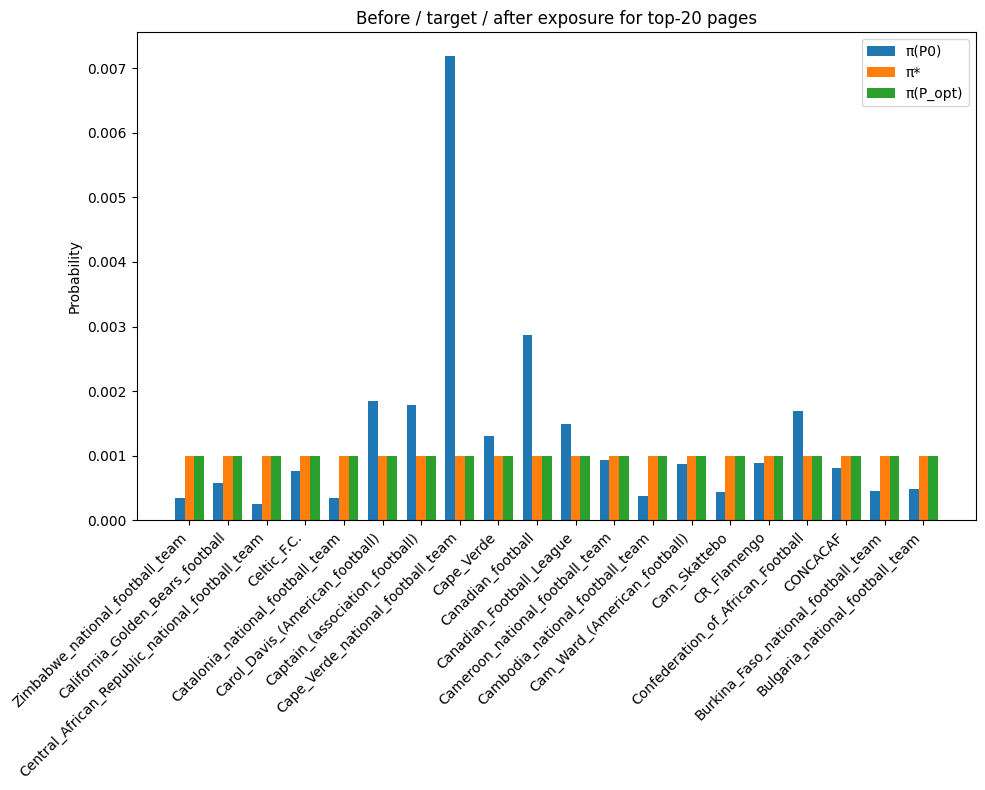

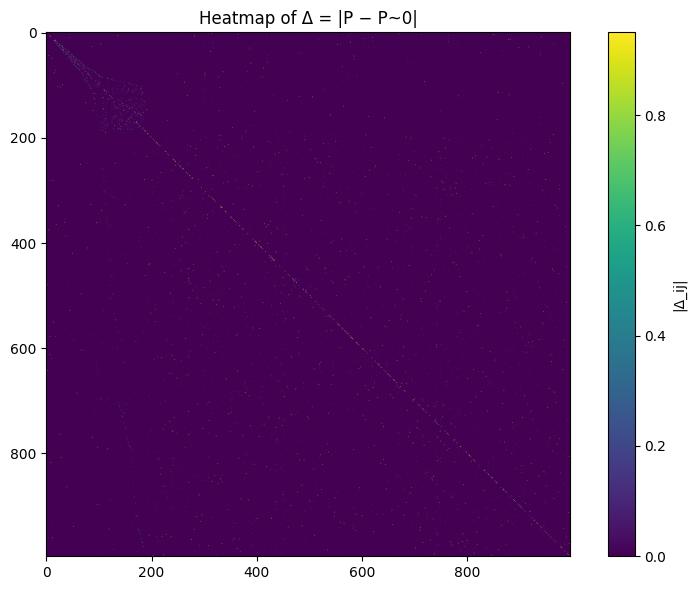

In [31]:
P_opt, t_edges, edges = solve_tsdp_Linf(
    P_tilde0, pi_star, w, C=C, k_in=k_in, k_out=k_out
)
results = verify_solution(P_opt, pi_star)

if P_opt is None:
    print("LP infeasible")
else:
    results = calculate_metrics(P_tilde0, P_opt, pi_star, edges)

plot_exposure_bars(P_tilde0, P_opt, pi_star, labels=pages, top_k=20)
plot_delta_heatmap(P_tilde0, P_opt, labels=pages)

### L 1

[INFO] n=996, |Ω|=19512
[INFO] Running HiGHS...
[INFO] LP solved.

===== FEASIBILITY CHECK =====
max |P1 - 1|       = 1.665e-15   (target < 1e-09)
min P_ij           = 0.000e+00     (allowed >= -1e-12)
Deviation L1(pi(P), pi_star) = 1.736e-14   (target < 1e-08)
Feasible? True

=== TSDP Evaluation ===
Edit cost (sum c_ij * |Δ_ij|): 604.877730
‖Δ‖_1:  604.877730
‖Δ‖_∞:  0.950050
Sparsity: 0.990491
‖π(P_opt) − π*‖_1: 1.7363280951920856e-14

Mixing proxy ‖P^k − 1π*^T‖_1:
  k= 1: 1862.476420
  k= 2: 1688.910296
  k= 5: 1123.597741
  k=10: 653.230891
  k=20: 318.566778


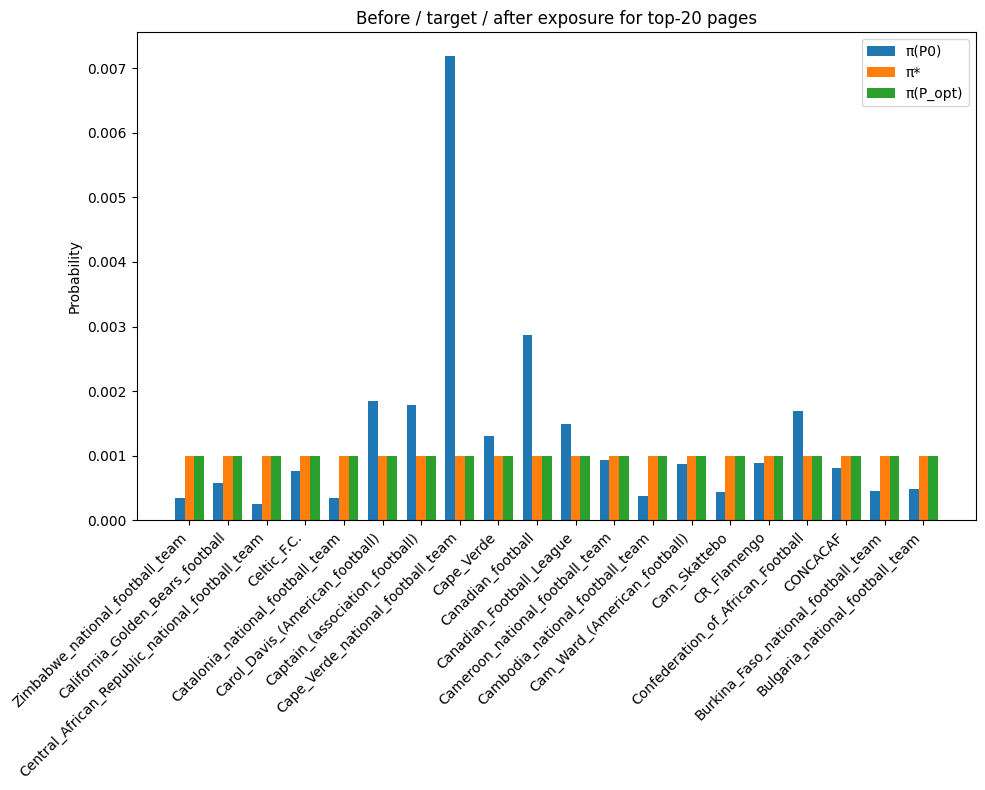

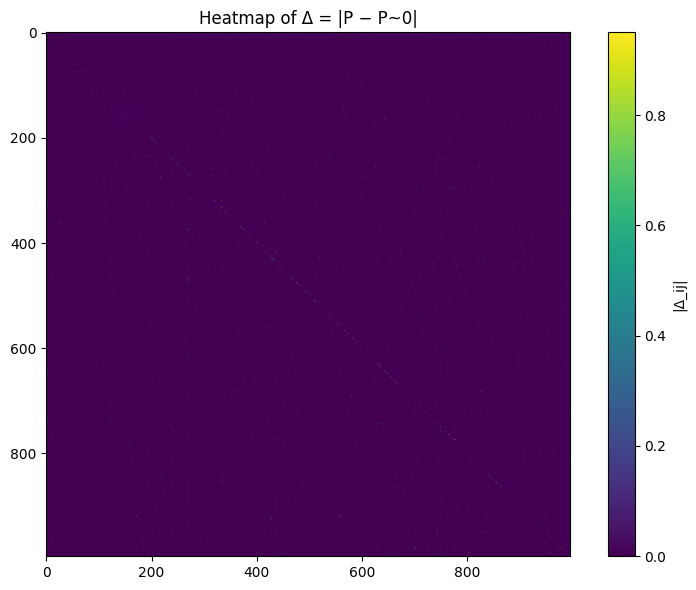

In [32]:
P_opt, t_edges, edges = solve_tsdp_L1(P_tilde0, pi_star, w, C=C, k_in=k_in, k_out=k_out)
results = verify_solution(P_opt, pi_star)

if P_opt is None:
    print("LP infeasible")
else:
    results = calculate_metrics(P_tilde0, P_opt, pi_star, edges)

plot_exposure_bars(P_tilde0, P_opt, pi_star, labels=pages, top_k=20)
plot_delta_heatmap(P_tilde0, P_opt, labels=pages)

### L inf

[INFO] n=996, |Ω|=19512
[INFO] Running HiGHS (L_inf)...
[INFO] LP solved (L_inf).

===== FEASIBILITY CHECK =====
max |P1 - 1|       = 1.443e-15   (target < 1e-09)
min P_ij           = -0.000e+00     (allowed >= -1e-12)
Deviation L1(pi(P), pi_star) = 4.060e-14   (target < 1e-08)
Feasible? True

=== TSDP Evaluation ===
Edit cost (sum c_ij * |Δ_ij|): 1650.050187
‖Δ‖_1:  1650.050187
‖Δ‖_∞:  0.945231
Sparsity: 0.980333
‖π(P_opt) − π*‖_1: 4.060098611480267e-14

Mixing proxy ‖P^k − 1π*^T‖_1:
  k= 1: 1880.842729
  k= 2: 1777.124586
  k= 5: 1495.960652
  k=10: 1114.893547
  k=20: 604.336358


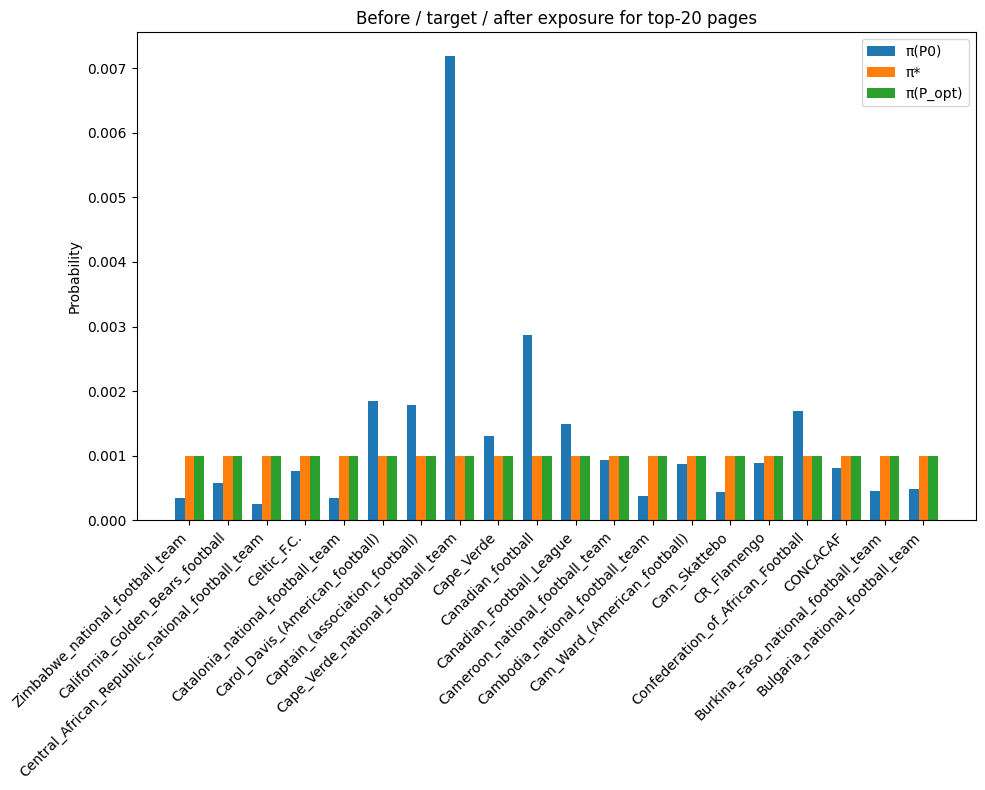

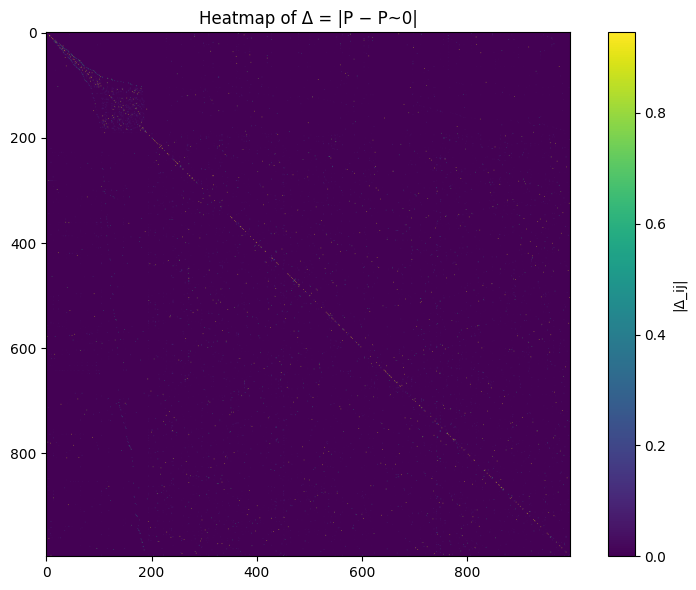

In [33]:
P_opt, t_edges, edges = solve_tsdp_Linf(P_tilde0, pi_star, w, k_in=k_in, k_out=k_out)
results = verify_solution(P_opt, pi_star)

if P_opt is None:
    print("LP infeasible")
else:
    results = calculate_metrics(P_tilde0, P_opt, pi_star, edges)

plot_exposure_bars(P_tilde0, P_opt, pi_star, labels=pages, top_k=20)
plot_delta_heatmap(P_tilde0, P_opt, labels=pages)

# Bonus

In [34]:
def solve_tsdp_L1_rmp(P_tilde0, pi_star, C, edges):
    n = P_tilde0.shape[0]
    m = len(edges)

    if C is None:
        C = np.ones_like(P_tilde0)

    num_P = m
    num_t = m
    num_vars = num_P + num_t

    outgoing = {i: [] for i in range(n)}
    incoming = {j: [] for j in range(n)}
    for e_idx, (i, j) in enumerate(edges):
        outgoing[i].append((e_idx, j))
        incoming[j].append((e_idx, i))

    c = np.zeros(num_vars)
    c[num_P:] = [C[i, j] for (i, j) in edges]

    data_r, rows_r, cols_r = [], [], []
    b_rows = np.zeros(n)

    for i in range(n):
        js_omega = {j for (_, j) in outgoing[i]}
        Bi = P_tilde0[i].sum() - sum(P_tilde0[i, j] for j in js_omega)
        b_rows[i] = 1.0 - Bi

        for e_idx, _ in outgoing[i]:
            rows_r.append(i)
            cols_r.append(e_idx)
            data_r.append(1.0)

    A_rows = csr_matrix((data_r, (rows_r, cols_r)), shape=(n, num_vars))

    data_s, rows_s, cols_s = [], [], []
    RHS_stat = np.zeros(n)

    for j in range(n):
        is_omega = {i for (_, i) in incoming[j]}
        Sj = sum(pi_star[i] * P_tilde0[i, j] for i in range(n) if i not in is_omega)
        RHS_stat[j] = pi_star[j] - Sj

        for e_idx, i in incoming[j]:
            rows_s.append(j)
            cols_s.append(e_idx)
            data_s.append(pi_star[i])

    A_stat = csr_matrix((data_s, (rows_s, cols_s)), shape=(n, num_vars))

    A_eq = vstack([A_rows, A_stat], format="csr")
    b_eq = np.concatenate([b_rows, RHS_stat])

    data_u, rows_u, cols_u = [], [], []
    b_ub = np.zeros(2 * m)

    for k, (i, j) in enumerate(edges):
        idxP = k
        idxT = m + k
        P0 = P_tilde0[i, j]

        rows_u.extend([2 * k, 2 * k])
        cols_u.extend([idxP, idxT])
        data_u.extend([1.0, -1.0])
        b_ub[2 * k] = P0

        rows_u.extend([2 * k + 1, 2 * k + 1])
        cols_u.extend([idxP, idxT])
        data_u.extend([-1.0, -1.0])
        b_ub[2 * k + 1] = -P0

    A_ub = csr_matrix((data_u, (rows_u, cols_u)), shape=(2 * m, num_vars))

    bounds = [(0.0, 1.0)] * num_P + [(0.0, None)] * num_t

    print("[INFO] Solving RMP with |Ω_R| =", m)
    res = linprog(
        c,
        A_eq=A_eq,
        b_eq=b_eq,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=bounds,
        method="highs",
    )

    if not res.success:
        print("[ERROR] RMP failed:", res.message)
        return None, None, res

    x = res.x
    P_edges = x[:num_P]
    t_edges = x[num_P:]

    P_opt = P_tilde0.copy()
    for val, (i, j) in zip(P_edges, edges):
        P_opt[i, j] = val

    return P_opt, t_edges, res


def extract_gamma(res, m):
    dual_ub = res.ineqlin.marginals
    u = dual_ub[0::2]
    v = dual_ub[1::2]
    gamma = u - v
    return gamma


def extract_duals(res, n):
    dual_eq = res.eqlin.marginals
    alpha = dual_eq[:n].copy()
    beta = dual_eq[n:].copy()
    return alpha, beta


def price_candidates(P_tilde0, pi_star, C, edges, alpha, beta, M=10, tol=1e-8):
    n = P_tilde0.shape[0]
    if C is None:
        C = np.ones_like(P_tilde0)

    S = alpha[:, None] + (pi_star[:, None]) * beta[None, :] + C

    mask_existing = np.zeros_like(P_tilde0, dtype=bool)
    for i, j in edges:
        mask_existing[i, j] = True

    S[mask_existing] = -np.inf

    flat = S.ravel()
    cand_idx = np.where(flat > tol)[0]

    if cand_idx.size == 0:
        return []

    if cand_idx.size > M:
        local = flat[cand_idx]
        top_local_idx = np.argpartition(local, -M)[-M:]
        best_idx = cand_idx[top_local_idx]
    else:
        best_idx = cand_idx

    new_edges = []
    for idx in best_idx:
        i = idx // n
        j = idx % n
        new_edges.append((int(i), int(j)))

    return new_edges


def initial_edges(w, P_tilde0, pi_star, k_in=10, k_out=10):
    n = P_tilde0.shape[0]
    edges_set = {(int(i), int(j)) for i, j in np.argwhere(w > 0)}

    for i in range(n):
        edges_set.add((i, i))
        js = np.argsort(P_tilde0[i])[::-1][:k_out]
        for j in js:
            edges_set.add((i, int(j)))

    for j in range(n):
        if pi_star[j] > 0 and not any((i, j) in edges_set for i in range(n)):
            isrc = np.argsort(P_tilde0[:, j])[::-1][:k_in]
            for i in isrc:
                edges_set.add((int(i), j))

    return sorted(edges_set)


def solve_tsdp_L1_column_generation(
    P_tilde0,
    pi_star,
    w,
    C=None,
    k_in=10,
    k_out=10,
    M=10,
    max_iter=10,
    tol=1e-8,
):
    n = P_tilde0.shape[0]
    if C is None:
        C = np.ones_like(P_tilde0)

    edges = initial_edges(w, P_tilde0, pi_star, k_in=k_in, k_out=k_out)
    history_objs = []
    history_L1 = []
    history_size = []

    for it in range(max_iter):
        print(f"\n==== CG iteration {it} |Ω_R|={len(edges)} ====")

        P_opt, t_opt, res = solve_tsdp_L1_rmp(P_tilde0, pi_star, C, edges)
        if P_opt is None:
            print("[WARN] RMP infeasible, stopping.")
            break

        obj = res.fun
        Delta = np.abs(P_opt - P_tilde0)
        L1 = np.sum(Delta)

        history_objs.append(obj)
        history_L1.append(L1)
        history_size.append(len(edges))

        print(f"[INFO] Obj = {obj:.6f}, ||Δ||_1 = {L1:.6f}")

        alpha, beta = extract_duals(res, n)
        gamma = extract_gamma(res, m=len(edges))

        new_edges = price_candidates(
            P_tilde0,
            pi_star,
            C,
            edges,
            alpha,
            beta,
            M=M,
            tol=tol,
        )
        if not new_edges:
            print("[INFO] No candidates with positive safe score. Stopping.")
            break

        print(f"[INFO] Adding {len(new_edges)} new edges.")
        edges = edges + [e for e in new_edges if e not in edges]

    return P_opt, history_objs, history_L1, history_size, edges

In [35]:
P0_full, P_tilde_full, w_full = build_P(df_sub, n, alpha=0.05)

pi_base_full = stationary_distribution(P_tilde_full)

k = 20
top_idx = np.argsort(pi_base_full)[::-1][:k]

mask = df_sub["i"].isin(top_idx) & df_sub["j"].isin(top_idx)
df_sub_k = df_sub[mask].copy()

mapping = {old: new for new, old in enumerate(top_idx)}
df_sub_k["i"] = df_sub_k["i"].map(mapping)
df_sub_k["j"] = df_sub_k["j"].map(mapping)

P0_sub, P_tilde_sub, w_sub = build_P(df_sub_k, n=k, alpha=0.05)

pi_star_sub = np.ones(k) / k

In [36]:
P_cg, objs, L1s, sizes, edges_cg = solve_tsdp_L1_column_generation(
    P_tilde_sub,
    pi_star_sub,
    w_sub,
    C=None,
    k_in=2,
    k_out=2,
    M=2,
    max_iter=10,
    tol=1e-6,
)

print("\n=== Column Generation iterations ===")
for it, (o, l1, s) in enumerate(zip(objs, L1s, sizes)):
    print(f"iter {it}: |Ω_R|={s}, obj={o:.6f}, ||Δ||_1={l1:.6f}")
print(f"final |Ω_R| = {len(edges_cg)}")

P_full, t_full, edges_full = solve_tsdp_L1(
    P_tilde_sub,
    pi_star_sub,
    w_sub,
    C=None,
    k_in=2,
    k_out=2,
)

C_sub = np.ones_like(P_tilde_sub)

obj_full = np.sum([C_sub[i, j] * t for t, (i, j) in zip(t_full, edges_full)])
L1_full = np.sum(np.abs(P_full - P_tilde_sub))

print("\n=== Full LP on the same subgraph ===")
print(f"Full LP: obj={obj_full:.6f}, ||Δ||_1={L1_full:.6f}")

print("\n=== Comparison CG vs Full LP ===")
print(f"CG last:  obj={objs[-1]:.6f}, ||Δ||_1={L1s[-1]:.6f}")
print(f"Full LP:  obj={obj_full:.6f}, ||Δ||_1={L1_full:.6f}")
print("max |P_full - P_cg| =", np.max(np.abs(P_full - P_cg)))


==== CG iteration 0 |Ω_R|=95 ====
[INFO] Solving RMP with |Ω_R| = 95
[INFO] Obj = 8.190626, ||Δ||_1 = 8.190626
[INFO] Adding 2 new edges.

==== CG iteration 1 |Ω_R|=97 ====
[INFO] Solving RMP with |Ω_R| = 97
[INFO] Obj = 8.096807, ||Δ||_1 = 8.096807
[INFO] Adding 2 new edges.

==== CG iteration 2 |Ω_R|=99 ====
[INFO] Solving RMP with |Ω_R| = 99
[INFO] Obj = 8.072638, ||Δ||_1 = 8.072638
[INFO] Adding 2 new edges.

==== CG iteration 3 |Ω_R|=101 ====
[INFO] Solving RMP with |Ω_R| = 101
[INFO] Obj = 8.072638, ||Δ||_1 = 8.072638
[INFO] Adding 2 new edges.

==== CG iteration 4 |Ω_R|=103 ====
[INFO] Solving RMP with |Ω_R| = 103
[INFO] Obj = 8.072638, ||Δ||_1 = 8.072638
[INFO] Adding 2 new edges.

==== CG iteration 5 |Ω_R|=105 ====
[INFO] Solving RMP with |Ω_R| = 105
[INFO] Obj = 8.072638, ||Δ||_1 = 8.072638
[INFO] Adding 2 new edges.

==== CG iteration 6 |Ω_R|=107 ====
[INFO] Solving RMP with |Ω_R| = 107
[INFO] Obj = 8.072638, ||Δ||_1 = 8.072638
[INFO] Adding 2 new edges.

==== CG iteration 